In [1]:
import pandas as pd
from tabulate import tabulate
from utils import PREPROCESSING_CONFIGS, VECTORIZER_CONFIGS, ALGORITHM_CONFIGS
import matplotlib.pyplot as plt
import seaborn as sns
from utils import TextPreprocessor, Word2VecVectorizer
from utils import RAW_DATA_DIR, OUTPUT_DATA_DIR
from wordcloud import WordCloud
import numpy as np
df = pd.read_csv(RAW_DATA_DIR / "spam_assassin.csv", nrows=5)

In [2]:
def load_results():
    """Load dimensionality study results"""
    results_path = OUTPUT_DATA_DIR / "experiments" / "dimensionality_study_results.csv"
    df = pd.read_csv(results_path)
    
    # Extract method type and components for better grouping
    df['method_type'] = df['dimensionality_method'].str.extract(r'([A-Za-z]+)')[0]
    df['method_type'] = df['method_type'].replace('SelectKBest', 'Feature Selection')
    df['method_type'] = df['method_type'].replace('baseline', 'No Reduction')
    
    # Calculate dimensionality reduction ratio
    df['reduction_ratio'] = df['n_components'] / df['original_features']
    
    return df
preprocessing_res = load_results()

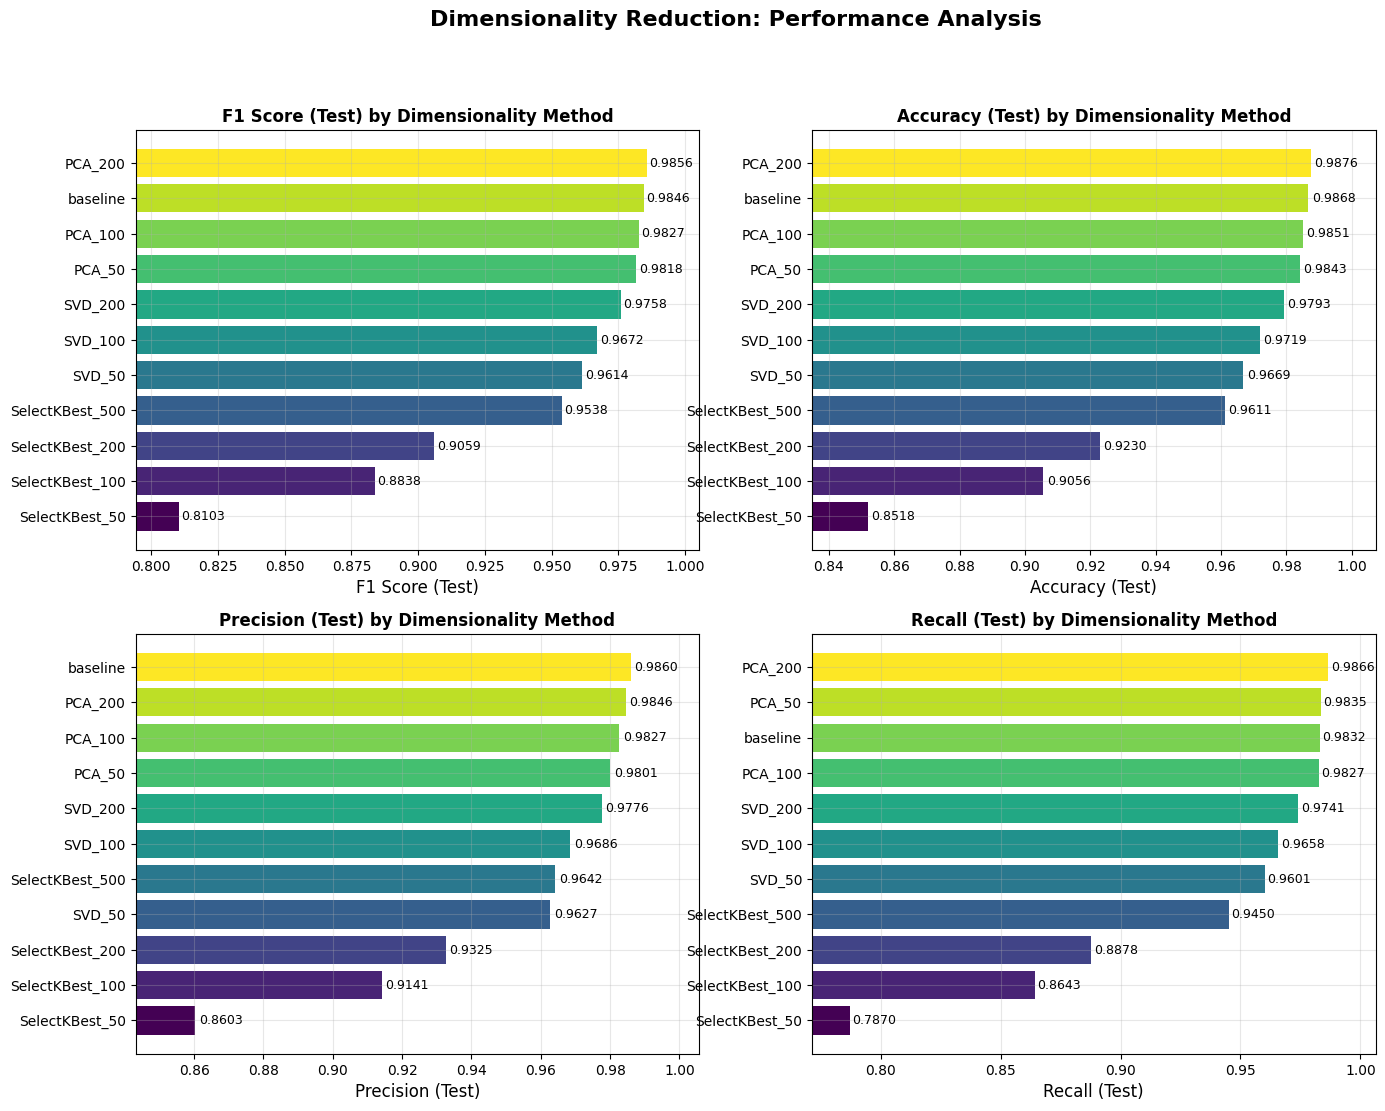

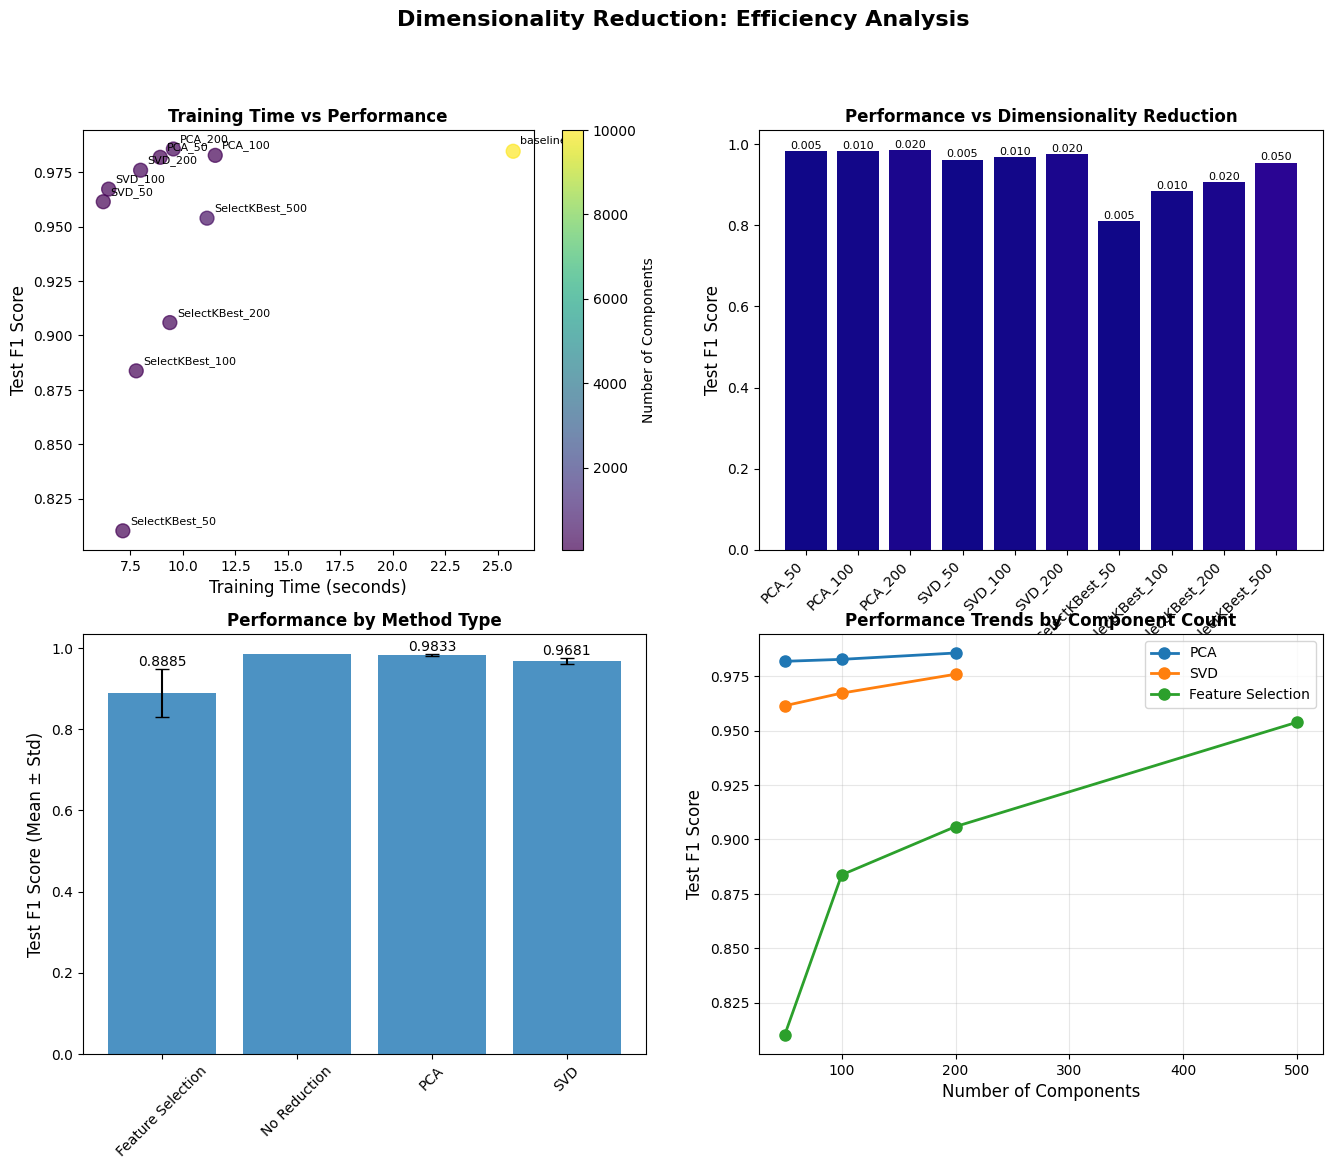

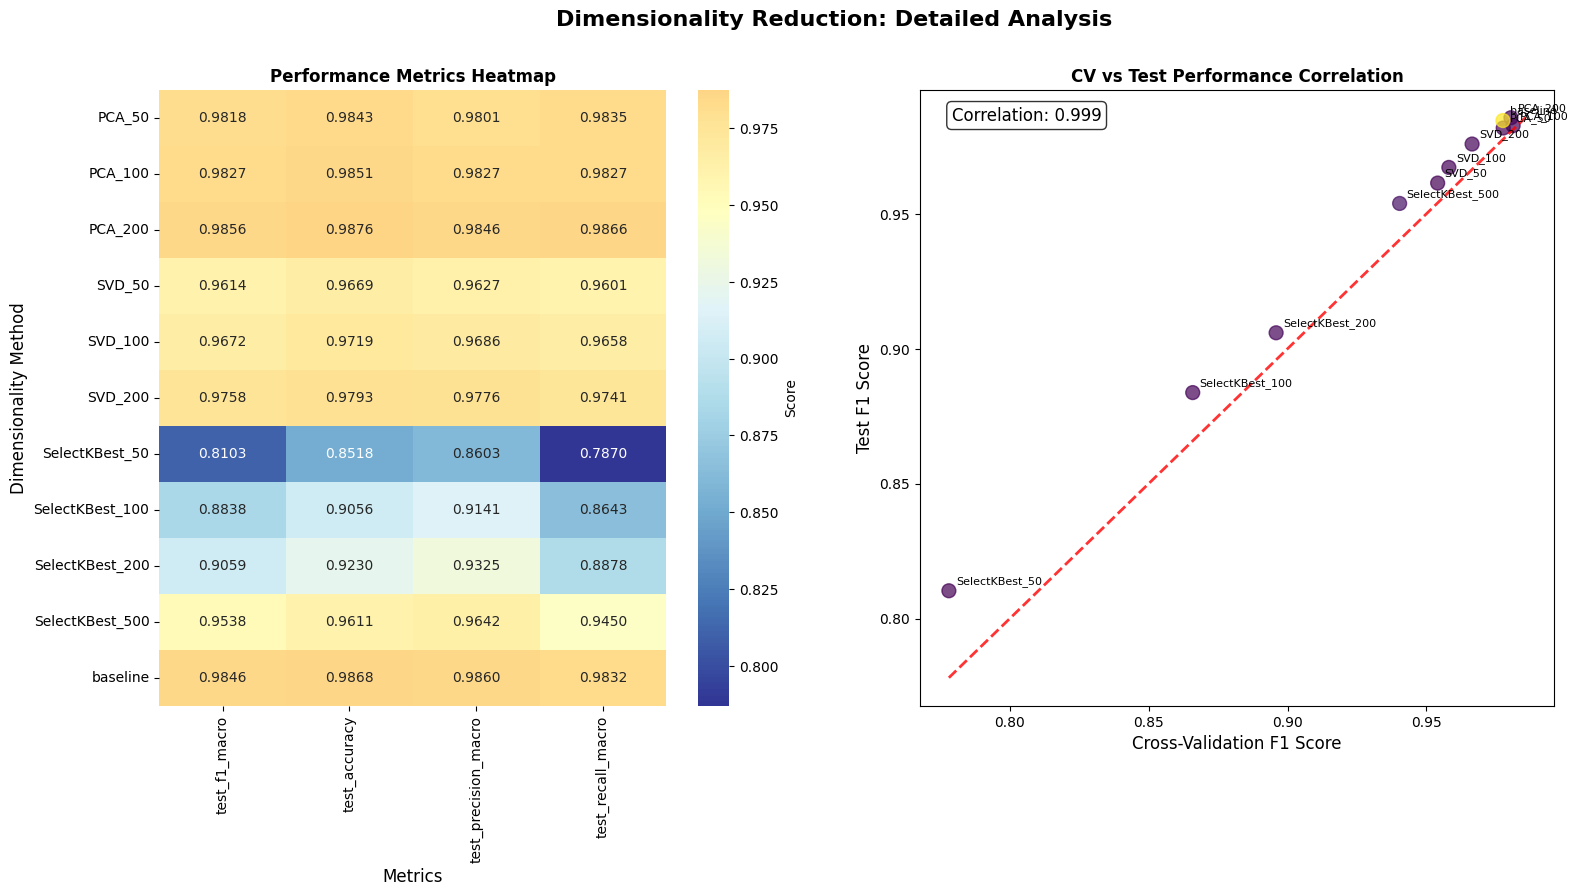

In [3]:
def create_performance_comparison(df):
    """Create performance comparison charts"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Dimensionality Reduction: Performance Analysis', fontsize=16, fontweight='bold')
    
    metrics = ['test_f1_macro', 'test_accuracy', 'test_precision_macro', 'test_recall_macro']
    titles = ['F1 Score (Test)', 'Accuracy (Test)', 'Precision (Test)', 'Recall (Test)']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 2, idx % 2]
        
        # Sort by performance for better visualization
        df_sorted = df.sort_values(metric, ascending=True)
        
        # Create horizontal bar plot
        bars = ax.barh(range(len(df_sorted)), df_sorted[metric], 
                      color=plt.cm.viridis(np.linspace(0, 1, len(df_sorted))))
        
        # Customize the plot
        ax.set_yticks(range(len(df_sorted)))
        ax.set_yticklabels(df_sorted['dimensionality_method'], fontsize=10)
        ax.set_xlabel(title, fontsize=12)
        ax.set_title(f'{title} by Dimensionality Method', fontsize=12, fontweight='bold')
        
        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars, df_sorted[metric])):
            if pd.notna(value):
                ax.text(value + 0.001, bar.get_y() + bar.get_height()/2, 
                       f'{value:.4f}', va='center', fontsize=9)
        
        ax.set_xlim(df_sorted[metric].min() * 0.98, df_sorted[metric].max() * 1.02)
        ax.grid(True, alpha=0.3)
    

def create_efficiency_analysis(df):
    """Create efficiency analysis charts"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Dimensionality Reduction: Efficiency Analysis', fontsize=16, fontweight='bold')
    
    # 1. Training Time vs Performance
    ax1 = axes[0, 0]
    scatter = ax1.scatter(df['training_time'], df['test_f1_macro'], 
                         c=df['n_components'], s=100, alpha=0.7, cmap='viridis')
    ax1.set_xlabel('Training Time (seconds)', fontsize=12)
    ax1.set_ylabel('Test F1 Score', fontsize=12)
    ax1.set_title('Training Time vs Performance', fontsize=12, fontweight='bold')
    
    # Add method labels
    for idx, row in df.iterrows():
        if pd.notna(row['test_f1_macro']):
            ax1.annotate(row['dimensionality_method'], 
                        (row['training_time'], row['test_f1_macro']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.colorbar(scatter, ax=ax1, label='Number of Components')
    
    # 2. Dimensionality Reduction Ratio vs Performance
    ax2 = axes[0, 1]
    df_filtered = df[df['dimensionality_method'] != 'baseline']
    bars = ax2.bar(range(len(df_filtered)), df_filtered['test_f1_macro'], 
                   color=plt.cm.plasma(df_filtered['reduction_ratio']))
    ax2.set_xticks(range(len(df_filtered)))
    ax2.set_xticklabels(df_filtered['dimensionality_method'], rotation=45, ha='right')
    ax2.set_ylabel('Test F1 Score', fontsize=12)
    ax2.set_title('Performance vs Dimensionality Reduction', fontsize=12, fontweight='bold')
    
    # Add reduction ratio labels
    for i, (bar, ratio) in enumerate(zip(bars, df_filtered['reduction_ratio'])):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{ratio:.3f}', ha='center', va='bottom', fontsize=8)
    
    # 3. Method Type Comparison
    ax3 = axes[1, 0]
    method_stats = df.groupby('method_type').agg({
        'test_f1_macro': ['mean', 'std'],
        'training_time': 'mean'
    }).round(4)
    
    method_stats.columns = ['F1_mean', 'F1_std', 'Time_mean']
    method_stats = method_stats.reset_index()
    
    bars = ax3.bar(method_stats['method_type'], method_stats['F1_mean'], 
                   yerr=method_stats['F1_std'], capsize=5, alpha=0.8)
    ax3.set_ylabel('Test F1 Score (Mean ± Std)', fontsize=12)
    ax3.set_title('Performance by Method Type', fontsize=12, fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar, mean, std in zip(bars, method_stats['F1_mean'], method_stats['F1_std']):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.001,
                f'{mean:.4f}', ha='center', va='bottom', fontsize=10)
    
    # 4. Components vs Performance Trend
    ax4 = axes[1, 1]
    
    # Group by method type and plot trends
    for method_type in df['method_type'].unique():
        if method_type != 'No Reduction':
            subset = df[df['method_type'] == method_type].sort_values('n_components')
            if len(subset) > 1:
                ax4.plot(subset['n_components'], subset['test_f1_macro'], 
                        marker='o', linewidth=2, markersize=8, label=method_type)
    
    ax4.set_xlabel('Number of Components', fontsize=12)
    ax4.set_ylabel('Test F1 Score', fontsize=12)
    ax4.set_title('Performance Trends by Component Count', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    

def create_detailed_comparison(df):
    """Create detailed comparison heatmap and statistical analysis"""
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('Dimensionality Reduction: Detailed Analysis', fontsize=16, fontweight='bold')
    
    # 1. Performance Heatmap
    ax1 = axes[0]
    
    # Select key metrics for heatmap
    metrics = ['test_f1_macro', 'test_accuracy', 'test_precision_macro', 'test_recall_macro']
    heatmap_data = df.set_index('dimensionality_method')[metrics]
    
    # Handle NaN values
    heatmap_data = heatmap_data.fillna(0)
    
    sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlBu_r', 
                center=heatmap_data.mean().mean(), ax=ax1, cbar_kws={'label': 'Score'})
    ax1.set_title('Performance Metrics Heatmap', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Metrics', fontsize=12)
    ax1.set_ylabel('Dimensionality Method', fontsize=12)
    
    # 2. CV vs Test Performance Comparison
    ax2 = axes[1]
    
    # Filter out rows with NaN test scores
    df_clean = df.dropna(subset=['test_f1_macro'])
    
    ax2.scatter(df_clean['cv_test_f1_macro'], df_clean['test_f1_macro'], 
               s=100, alpha=0.7, c=df_clean['n_components'], cmap='viridis')
    
    # Add diagonal line for perfect correlation
    min_val = min(df_clean['cv_test_f1_macro'].min(), df_clean['test_f1_macro'].min())
    max_val = max(df_clean['cv_test_f1_macro'].max(), df_clean['test_f1_macro'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
    
    ax2.set_xlabel('Cross-Validation F1 Score', fontsize=12)
    ax2.set_ylabel('Test F1 Score', fontsize=12)
    ax2.set_title('CV vs Test Performance Correlation', fontsize=12, fontweight='bold')
    
    # Add method labels
    for idx, row in df_clean.iterrows():
        ax2.annotate(row['dimensionality_method'], 
                    (row['cv_test_f1_macro'], row['test_f1_macro']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Calculate and display correlation
    correlation = df_clean['cv_test_f1_macro'].corr(df_clean['test_f1_macro'])
    ax2.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
             transform=ax2.transAxes, fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
create_performance_comparison(preprocessing_res)
create_efficiency_analysis(preprocessing_res)
create_detailed_comparison(preprocessing_res)
